## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Getting The Data

In [2]:
df = pd.read_csv("output1.csv") 


## Let's apply head & describe to the Data

In [3]:
df.head()

,Unnamed: 0,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


In [4]:
df.describe()

,Unnamed: 0,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,499.500000,1055.071157,991.851567,1529.373525,495.107156,940.590072,1550.637455,1561.003252,561.346117,1089.067338,1452.521629,0.50000
std,288.819436,370.980193,392.278890,640.286092,142.789188,345.923136,493.491988,598.608517,247.357552,402.666953,568.132005,0.50025
min,0.000000,21.170000,21.720000,31.800000,8.450000,17.930000,27.930000,31.960000,13.520000,23.210000,30.890000,0.00000
25%,249.750000,767.413366,694.859326,1062.600806,401.788135,700.763295,1219.267077,1132.097865,381.704293,801.849802,1059.499689,0.00000
50%,499.500000,1045.904805,978.355081,1522.507269,500.197421,939.348662,1564.996551,1565.882879,540.420379,1099.087954,1441.554053,0.50000
75%,749.250000,1326.065178,1275.528770,1991.128626,600.525709,1182.578166,1891.937040,1981.739411,725.762027,1369.923665,1864.405512,1.00000
max,999.000000,2117.000000,2172.000000,3180.000000,845.000000,1793.000000,2793.000000,3196.000000,1352.000000,2321.000000,3089.000000,1.00000


## EDA

### Let's use seaborn on the dataframe to create a pairplot with the hue indicated by the TARGET CLASS column.

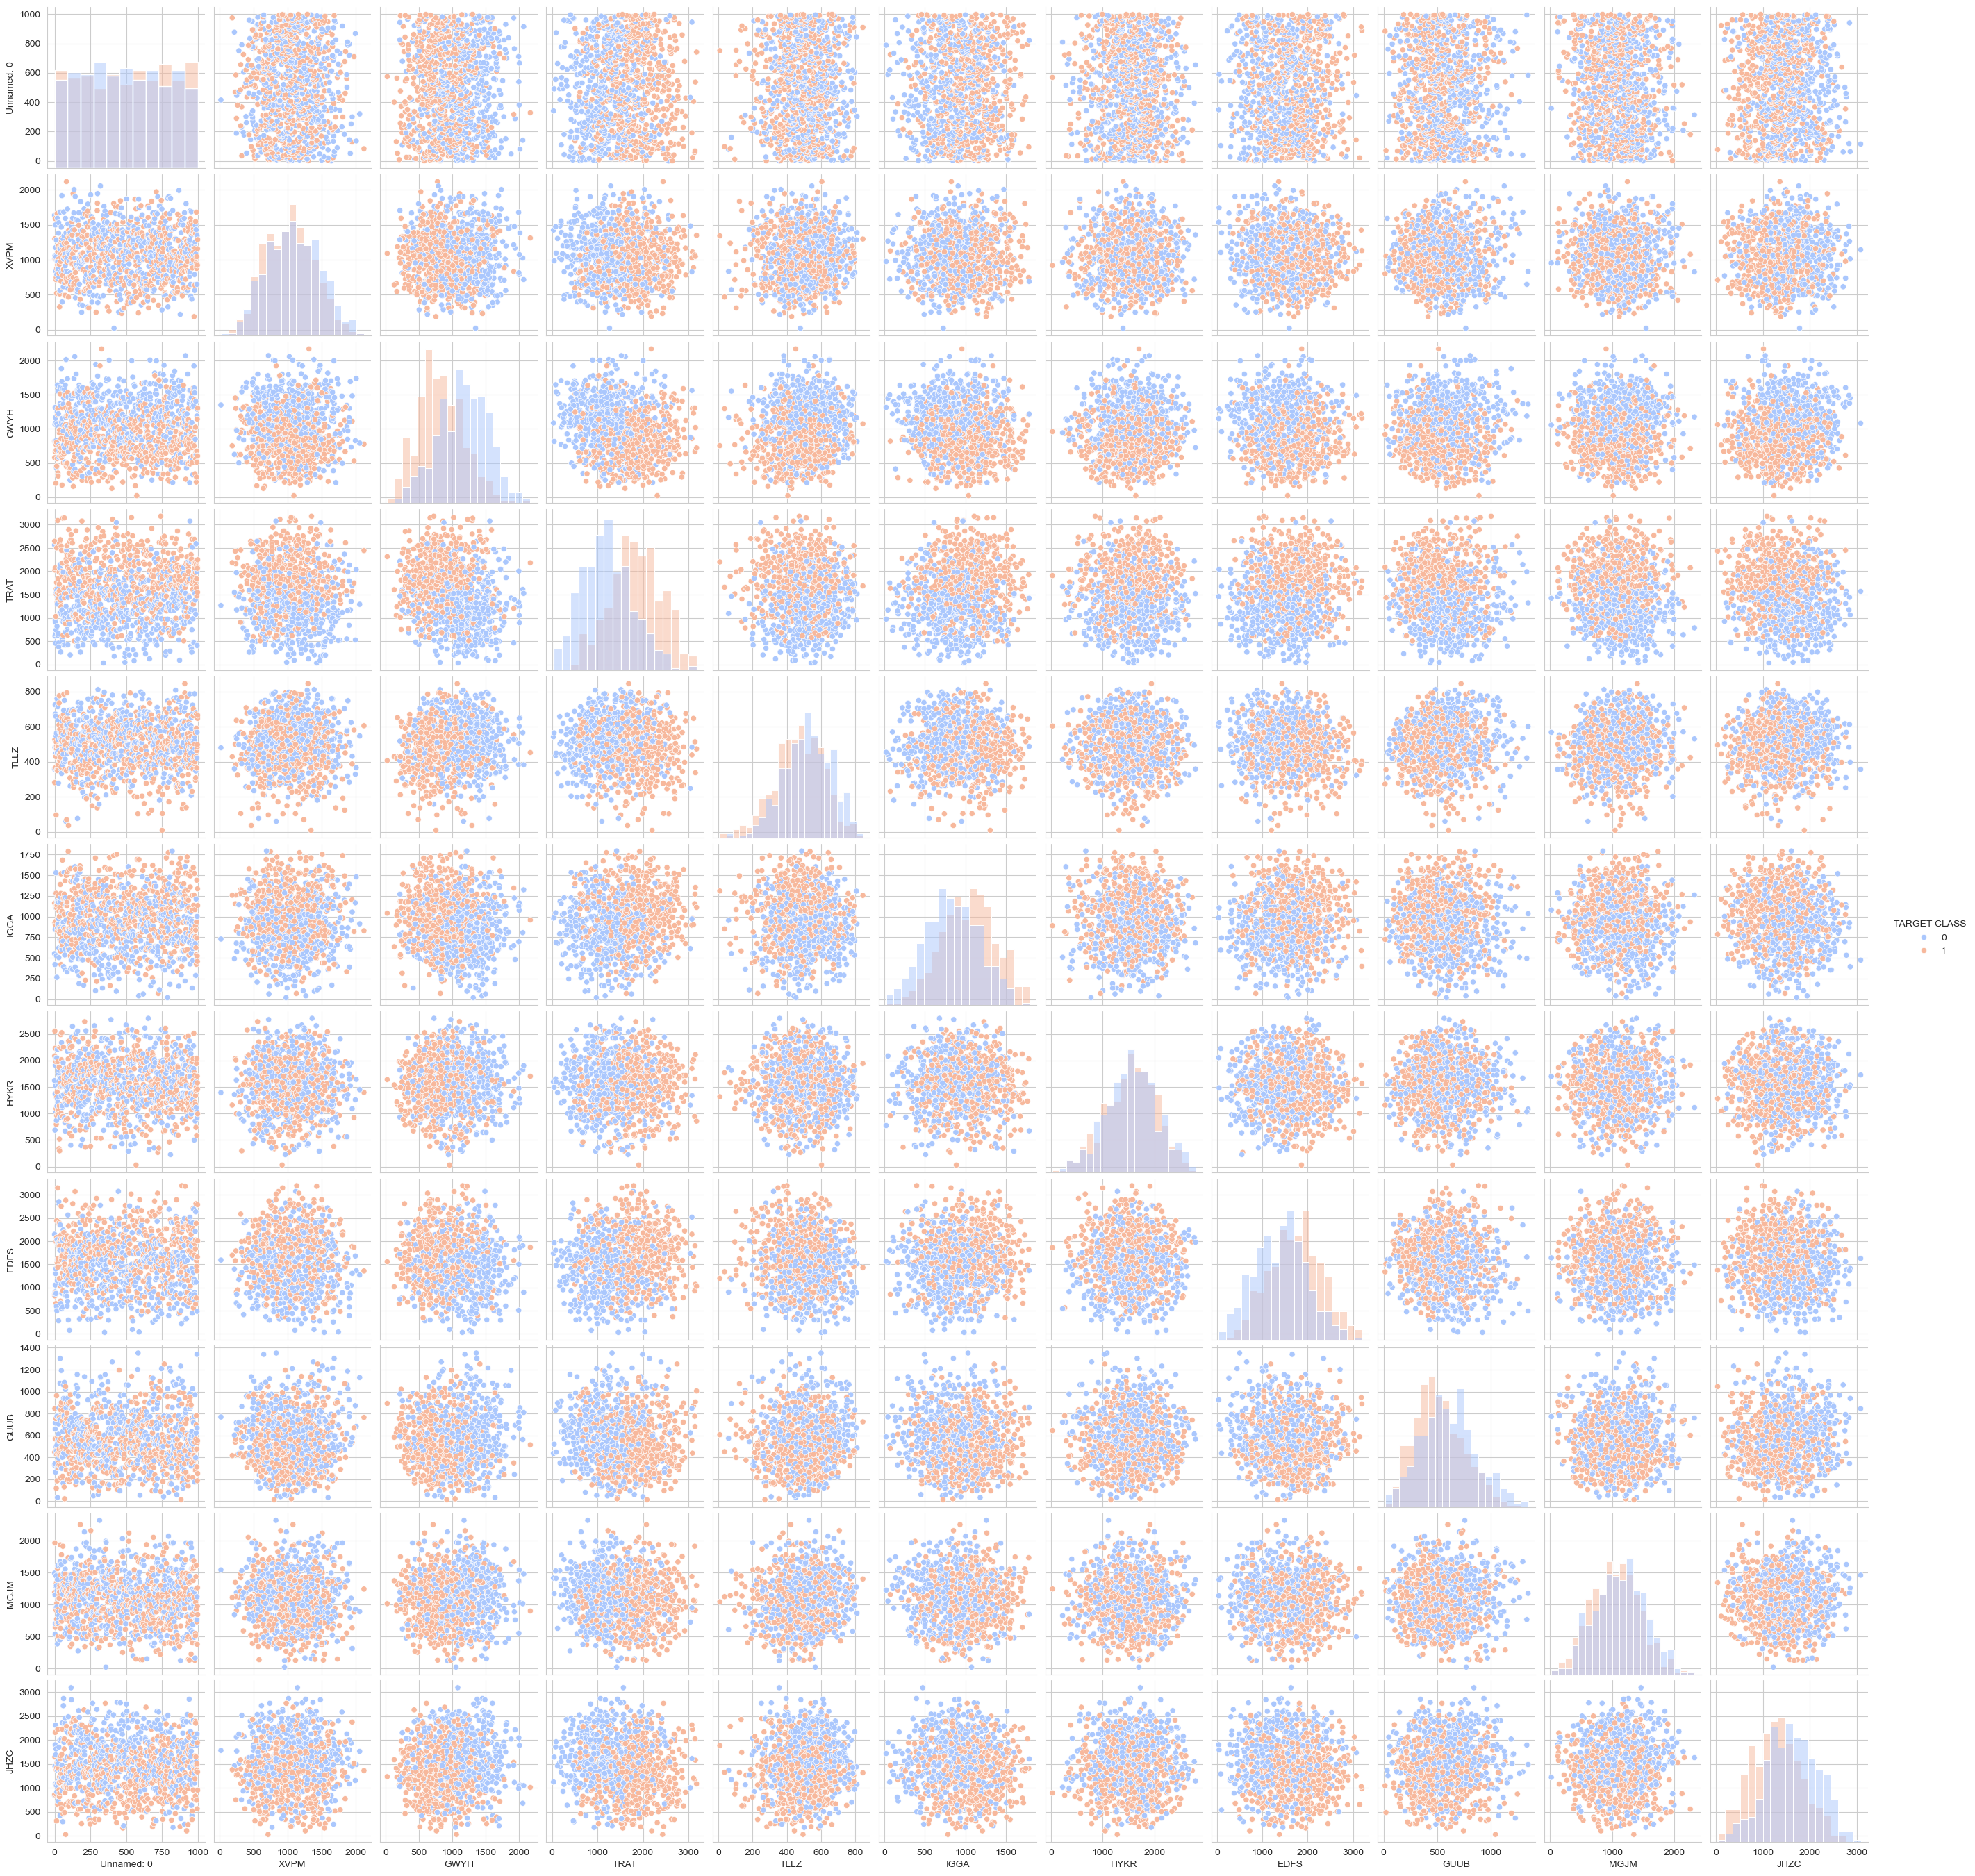

In [5]:
sns.set_style('whitegrid')
sns.pairplot(df,hue='TARGET CLASS',diag_kind='hist',palette='coolwarm')

## Standardizing the variables

#### We have wide range of data with us, so we need scaling. Let's use srandard scaler to rescale our feature to same scale and which is robust to outliers

In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
scaler = StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split
X = df[['XVPM',"GWYH","TRAT","TLLZ","IGGA","HYKR","EDFS","GUUB","MGJM","JHZC"]]
y = df["TARGET CLASS"]

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# scale data

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Using KNN

In [9]:
from sklearn.neighbors import KNeighborsClassifier

#### Create a KNN model instance with n_neighbors=1

In [10]:
Knn = KNeighborsClassifier(n_neighbors=1)

In [11]:
Knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

## Predictions and Evaluations

In [12]:
pred = Knn.predict(X_test)

In [13]:
from sklearn.metrics import classification_report,confusion_matrix

In [14]:
print(confusion_matrix(y_test,pred))

[[108  43]
 [ 24 125]]


In [15]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.82      0.72      0.76       151
           1       0.74      0.84      0.79       149

    accuracy                           0.78       300
   macro avg       0.78      0.78      0.78       300
weighted avg       0.78      0.78      0.78       300



## Choosing K value

In [16]:
error_rate = []

for i in range(1,10):

    Knn = KNeighborsClassifier(n_neighbors=i,metric='minkowski', p=1)
    Knn.fit(X_train,y_train)
    pred_i = Knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

Text(0, 0.5, 'Error Rate')

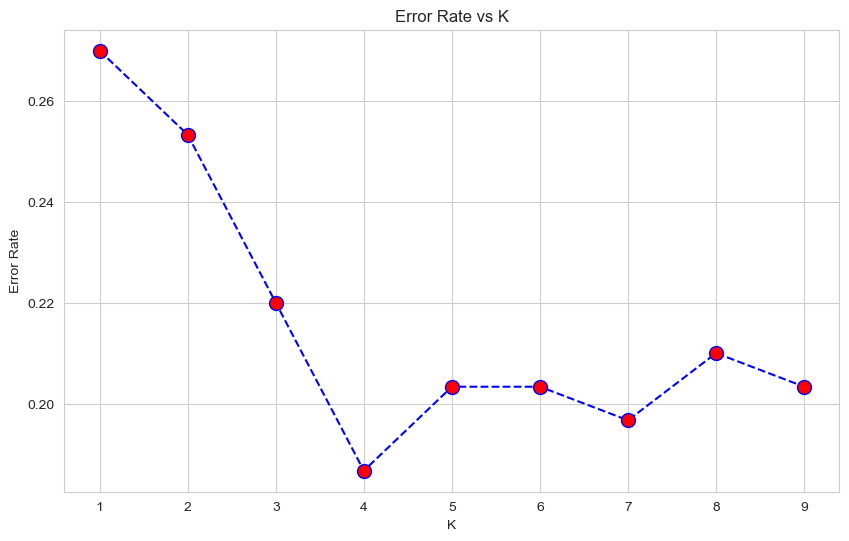

In [17]:
plt.figure(figsize=(10,6))
plt.plot(range(1,10),error_rate,color='blue',linestyle='--',marker='o',markerfacecolor='red',markersize=10)
plt.title('Error Rate vs K')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [18]:
Knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=1)
Knn.fit(X_train,y_train)
pred = Knn.predict(X_test)
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

[[115  36]
 [ 23 126]]


              precision    recall  f1-score   support

           0       0.83      0.76      0.80       151
           1       0.78      0.85      0.81       149

    accuracy                           0.80       300
   macro avg       0.81      0.80      0.80       300
weighted avg       0.81      0.80      0.80       300



In [19]:

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_neighbors': list(range(1, 50)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 44, 'weights': 'uniform'}


In [21]:
Knn = KNeighborsClassifier(metric= 'euclidean', n_neighbors= 44, weights= 'uniform')
Knn.fit(X_train,y_train)
pred = Knn.predict(X_test)
print(confusion_matrix(y_test,pred))
print('\n')
print(classification_report(y_test,pred))

[[120  31]
 [ 21 128]]


              precision    recall  f1-score   support

           0       0.85      0.79      0.82       151
           1       0.81      0.86      0.83       149

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300

